#Air Pollution Forecasting

데이터셋 : Kaggle의 Air Pollution Forecasting - LSTM Mutivariation

목표 : LSTM을 활용해 pollution 예측, 최대의 정확도를 구현하기, 시계열 데이터 올바르게 전처리하기

##데이터셋 로드

In [1]:
!pip install torchmetrics

In [2]:
!pip install optuna

In [3]:
!pip install torchviz

In [4]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import optuna
from torchviz import make_dot

In [5]:
zip_filename = 'air_pollution.zip'
extract_folder = './air_pollution'

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zipf:
    zipf.extractall(extract_folder)

##EDA

train 데이터와 test 데이터로 보이는 제목의 csv문서가 2개 있어서 보았다.

In [6]:
train_path = './air_pollution/LSTM-Multivariate_pollution.csv'
test_path = './air_pollution/pollution_test_data1.csv'

In [7]:
train_df = pd.read_csv(train_path)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       43800 non-null  object 
 1   pollution  43800 non-null  float64
 2   dew        43800 non-null  int64  
 3   temp       43800 non-null  float64
 4   press      43800 non-null  float64
 5   wnd_dir    43800 non-null  object 
 6   wnd_spd    43800 non-null  float64
 7   snow       43800 non-null  int64  
 8   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 3.0+ MB


In [8]:
train_df.head()

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
0,2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
1,2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2,2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
3,2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
4,2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [9]:
train_df.tail()

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
43795,2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43796,2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43797,2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43798,2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0
43799,2014-12-31 23:00:00,12.0,-21,-3.0,1034.0,NW,249.85,0,0


2010년 ~ 2014년의 데이터셋인것을 확인

date : 날짜

pollution : 오염 정도(타겟)

dew : 이슬점(공기중 수증기가 포화되어 응결되기 시작되는 온도)

temp : 온도

press : 기압

wind_dir : 퐁향

wnd_spd : 풍속

snow : 적설량

rain : 강우량


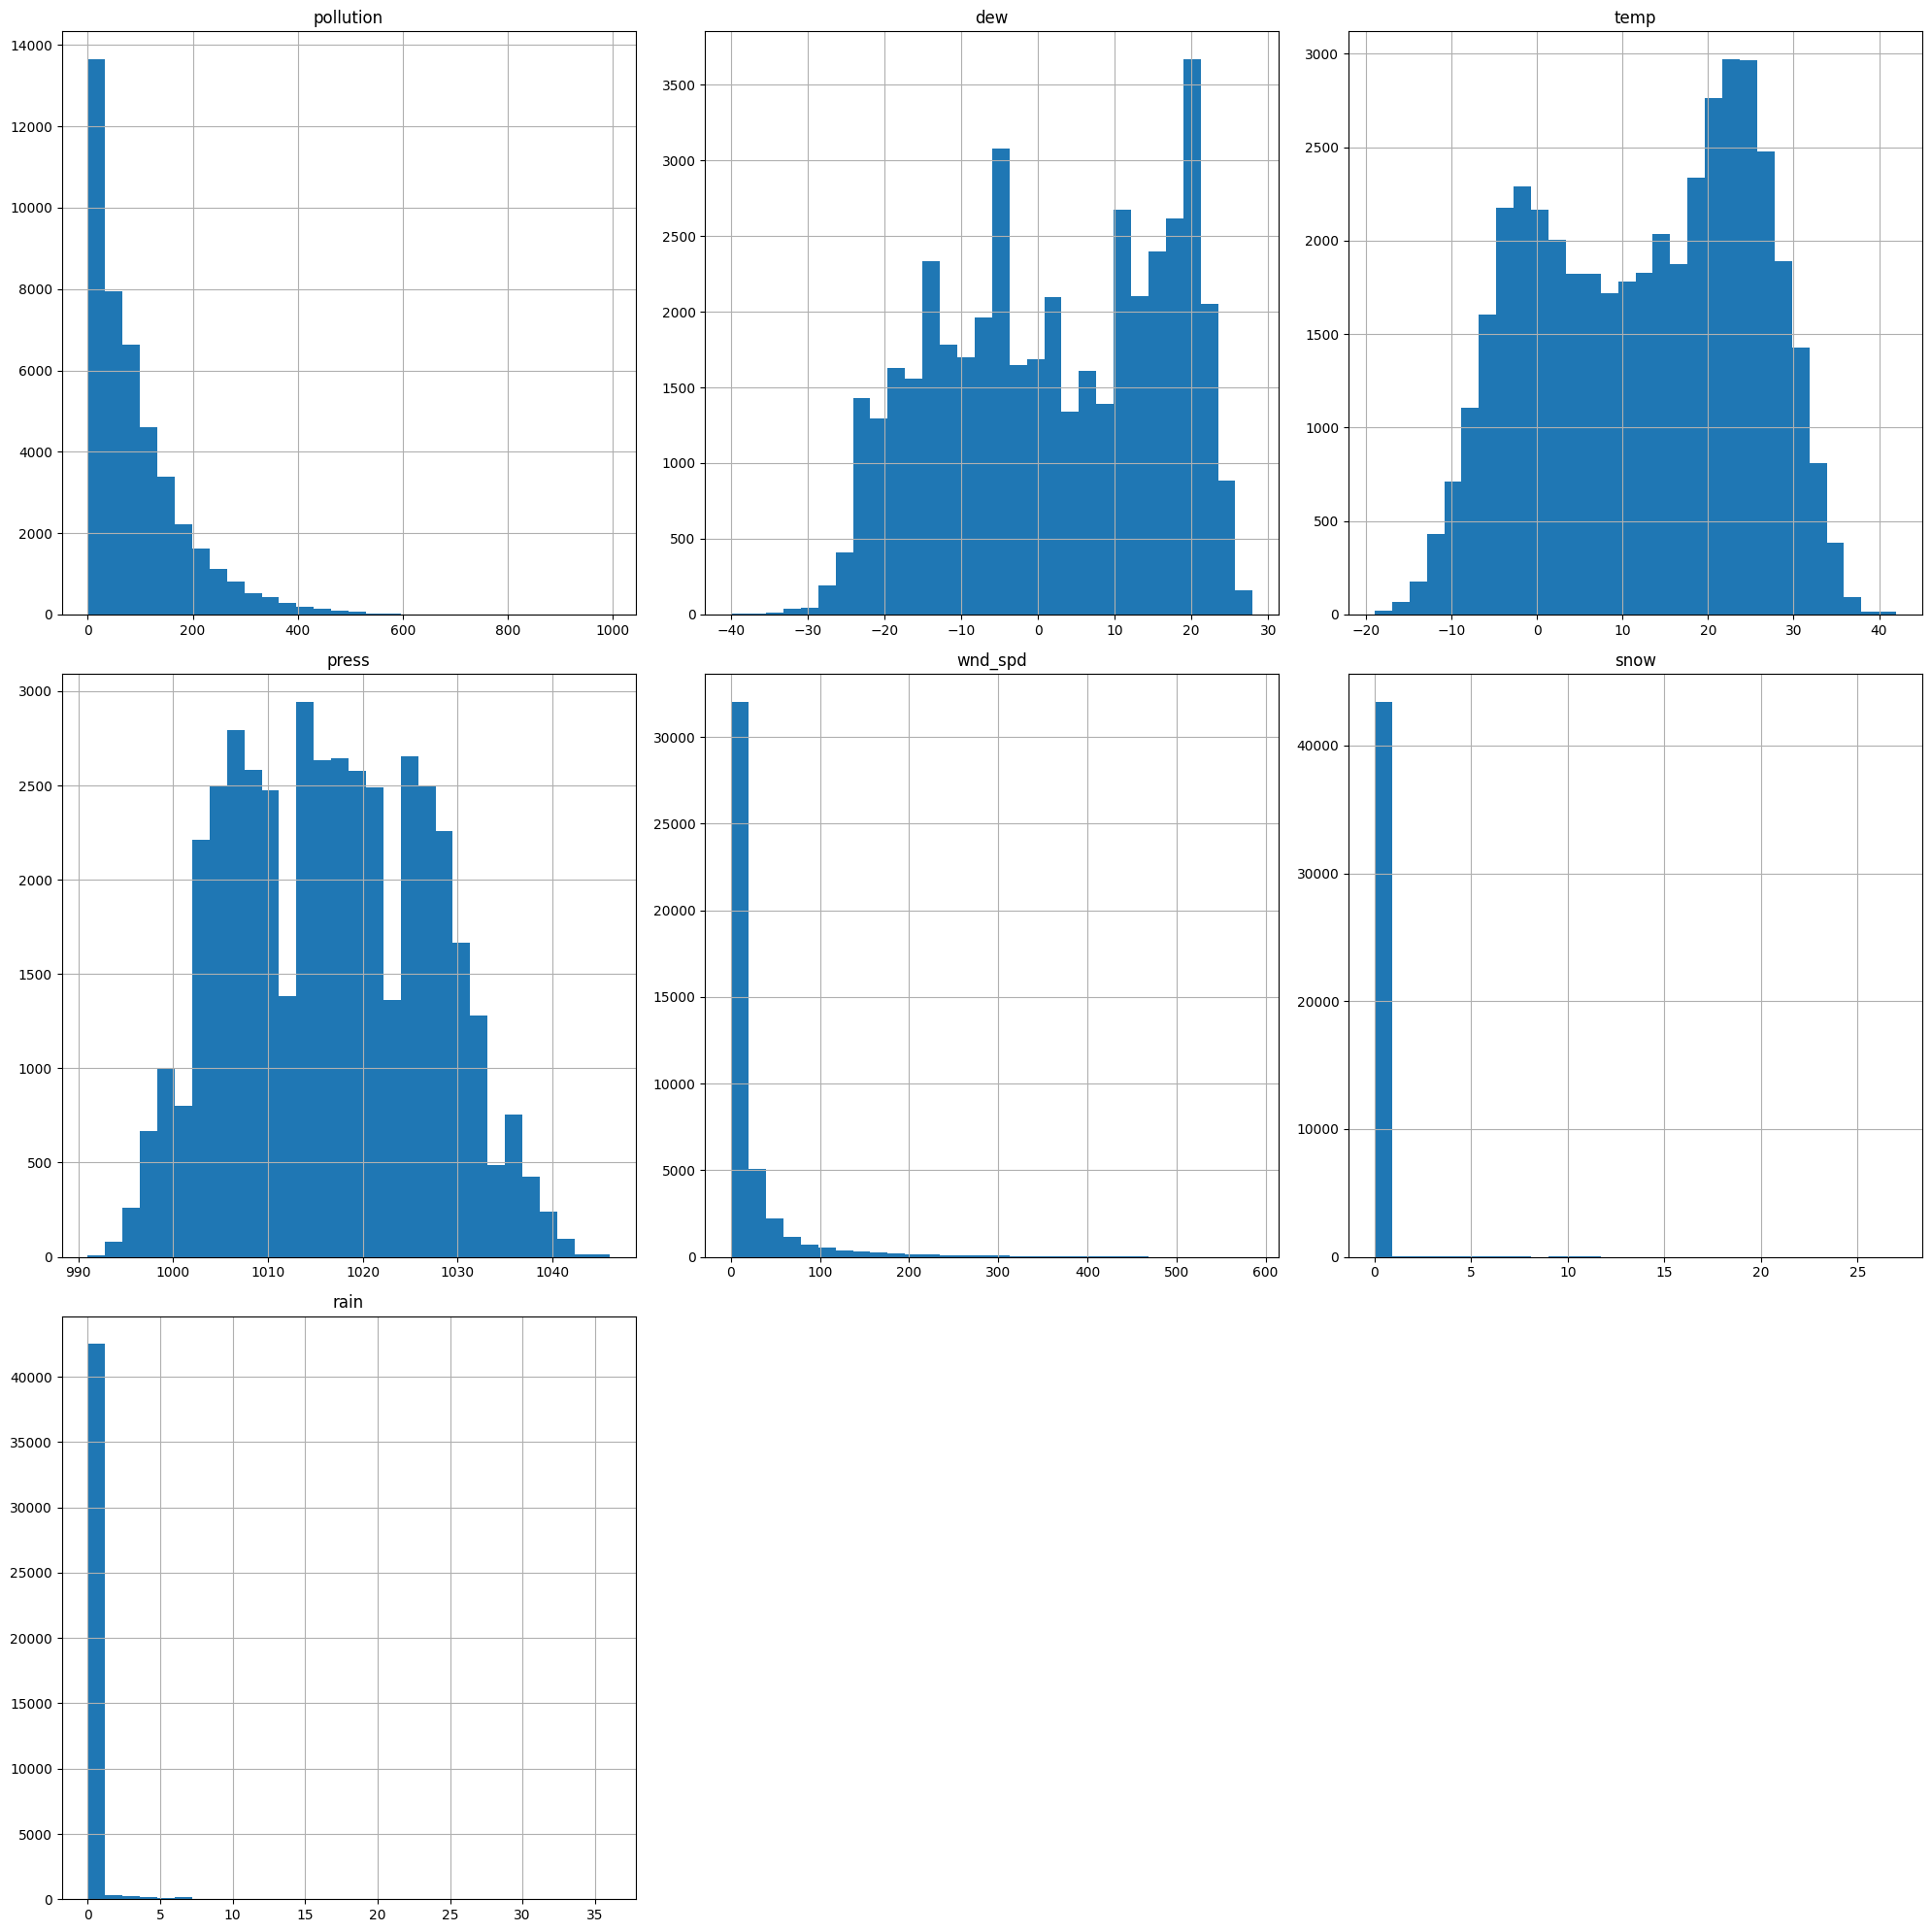

In [10]:
train_df.hist(bins = 30, figsize = (20, 20))
plt.tight_layout()
plt.show()

EDA를 위해 Copy 생성

In [11]:
train_df_eda = train_df.copy()

In [12]:
train_df_eda['wnd_dir'].value_counts()

,count
wnd_dir,
SE,15290
NW,14130
cv,9384
NE,4996


cv는 아마도 SW방향 인것 같음

In [13]:
train_df_eda['date'] = pd.to_datetime(train_df_eda['date'], format = '%Y-%m-%d %H:%M:%S')
train_df_eda.sort_values(by = 'date', inplace = True)

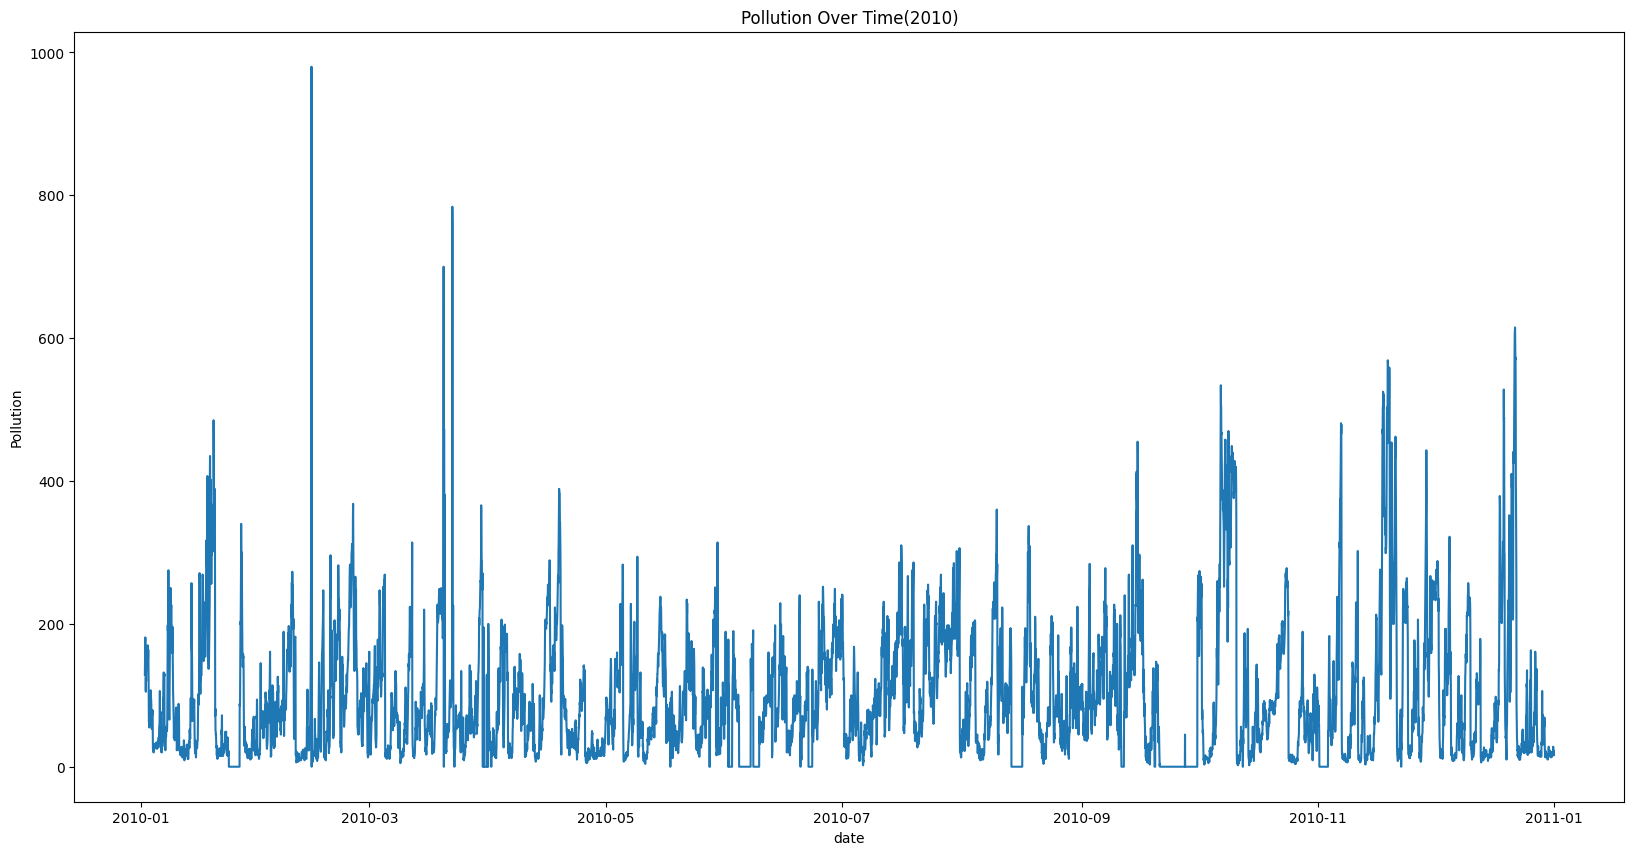

In [14]:
#시간에 따른 pollution 시각화
df_2010 = train_df_eda[train_df_eda['date'].dt.year == 2010]

plt.figure(figsize = (20, 10))
plt.plot(df_2010['date'], df_2010['pollution'])
plt.xlabel('date')
plt.ylabel('Pollution')
plt.title('Pollution Over Time(2010)')
plt.show()

In [15]:
test_df = pd.read_csv(test_path)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dew        346 non-null    int64  
 1   temp       346 non-null    int64  
 2   press      346 non-null    int64  
 3   wnd_dir    346 non-null    object 
 4   wnd_spd    346 non-null    float64
 5   snow       346 non-null    int64  
 6   rain       346 non-null    int64  
 7   pollution  346 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 21.8+ KB


test에는 date데이터가 없음, train data를 관찰했을 때는 season 열을 추가하려 했으나 test데이터셋에서 계절 추출이 불가하므로 특성 일치를 위해 추가하지 않기로 판단

##데이터셋 구축

validation Set의 경우에는 2014년의 데이터, train 데이터는 2014년 이전의 데이터를 활용했다.

In [16]:
#Train, Validation 데이터셋 구축
class PollutionDataset_Train_Val(Dataset):
  def __init__(self, csv_path, seq_len, mode = 'train', seq_x_scaler = None, encoder = None, y_scaler = None) :
    self.seq_len = seq_len

    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d %H:%M:%S')
    df.sort_values(by = 'date', inplace = True)

    seq_x = ['dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain']
    cate_x = ['wnd_dir']
    target = ['pollution']


    if mode == 'train': #Train Dataset
        df_subset = df[df['date'].dt.year < 2014]
    else: #Validation Dataset
        df_subset = df[df['date'].dt.year >= 2014]

    if mode == 'train' :  #Train Dataset
      self.seq_x_scaler = StandardScaler()
      self.encoder = OneHotEncoder(sparse_output = False)
      self.y_scaler = StandardScaler()

      self.seq_x = self.seq_x_scaler.fit_transform(df_subset[seq_x])
      self.cate_x = self.encoder.fit_transform(df_subset[cate_x])

      self.X = np.concatenate([self.seq_x, self.cate_x], axis = 1)

      self.Y = self.y_scaler.fit_transform(df_subset[target])

    else :  #Validation Dataset
      self.seq_x_scaler = seq_x_scaler
      self.encoder = encoder
      self.y_scaler = y_scaler

      self.seq_x = self.seq_x_scaler.transform(df_subset[seq_x])
      self.cate_x = self.encoder.transform(df_subset[cate_x])

      self.X = np.concatenate([self.seq_x, self.cate_x], axis = 1)

      self.Y = self.y_scaler.transform(df_subset[target])


  def __len__(self) :
    return len(self.X) - self.seq_len

  def __getitem__(self, idx) :
    x = self.X[idx : idx + self.seq_len]
    y = self.Y[idx + self.seq_len]

    return torch.tensor(x, dtype = torch.float32), torch.tensor(y, dtype = torch.float32)

In [17]:
#Test Dataset 구축
class PollutionDataset_Test(Dataset):
  def __init__(self, csv_path, seq_len, seq_x_scaler, encoder, y_scaler) :
    self.seq_len = seq_len

    df = pd.read_csv(csv_path)
   #Date Column이 없으므로 처리 불필요

    seq_x = ['dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain']
    cate_x = ['wnd_dir']
    target = ['pollution']

    self.seq_x_scaler = seq_x_scaler
    self.encoder = encoder
    self.y_scaler = y_scaler

    self.seq_x = self.seq_x_scaler.transform(df[seq_x])
    self.cate_x = self.encoder.transform(df[cate_x])

    self.X = np.concatenate([self.seq_x, self.cate_x], axis = 1)

    self.Y = self.y_scaler.transform(df[target])

  def __len__(self) :
    return len(self.X) - self.seq_len

  def __getitem__(self, idx) :
    x = self.X[idx : idx + self.seq_len]
    y = self.Y[idx + self.seq_len]
    return torch.tensor(x, dtype = torch.float32), torch.tensor(y, dtype = torch.float32)

In [18]:
#1시간마다 기록되어있으므로, 일주일을 하나의 seq로 잡음(24 * 7)
seq_len = 168

train_ds = PollutionDataset_Train_Val(train_path, seq_len)

val_ds = PollutionDataset_Train_Val(train_path, seq_len, mode = 'val',
                                    seq_x_scaler = train_ds.seq_x_scaler,
                                    encoder = train_ds.encoder,
                                    y_scaler = train_ds.y_scaler)

In [19]:
#DataLodaer 생성
train_loader = DataLoader(train_ds, batch_size = 128, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = 128, shuffle = False)

input_x, target_y = next(iter(train_loader))
print(f"Batch X Shape: {input_x.shape}")
print(f"Batch Y Shape: {target_y.shape}")

Batch X Shape: torch.Size([128, 168, 10])
Batch Y Shape: torch.Size([128, 1])


##모델링

In [20]:
class LSTMModel(nn.Module) :
  def __init__(self, input_size, hidden_size, num_layers, dropout) :
    super(LSTMModel, self).__init__()

    #LSTM 레이어
    self.lstm = nn.LSTM(input_size, hidden_size,
                        num_layers = num_layers,
                        batch_first = True, dropout = dropout)
    #레이어정규화
    self.ln = nn.LayerNorm(hidden_size)

    #ReLU 활성화
    self.relu = nn.ReLU()

    #선형변환 수행(최종 출력)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x) :
    x, _ = self.lstm(x)

    #마지막 타입스템 선택
    x = x[:, -1, :]

    x = self.ln(x)
    x = self.relu(x)
    output = self.fc(x)

    return output

##하이퍼파라미터 튜닝

수작업으로 찾는 것보다는 베이지안 기법을 쓰는것이 좋다고 판단하여, hidden_size, num_layers, dropout, weight_decay, learning_rate에 대해서 optuna를 활용하여 하이퍼파라미터 튜닝을 진행했다.

In [21]:
#gpu 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [22]:
import numpy as np
#optuna 활용

def objective(trial) :
  #하이퍼파라미터 튜닝 범위 설정
  hidden_size = trial.suggest_categorical('hidden_size', [16, 32, 64])
  num_layers = trial.suggest_int('num_layers', 3, 5,)
  dropout = trial.suggest_float('dropout', 0.1, 0.5)
  weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log = True)
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log = True)


  #모델 할당
  model = LSTMModel(input_size = 10, hidden_size = hidden_size,
                    num_layers = num_layers, dropout = dropout).to(device)

  #optimizer(AdamW) 설정
  optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate, weight_decay = weight_decay)

  criterion = nn.MSELoss()

  #학습
  best_rmse = float('inf') # RMSE는 낮을수록 좋으므로 초기값은 무한대로 설정
  epochs = 50
  for epoch in range(epochs) :
    model.train()
    for features, labels in train_loader :
      features = features.to(device)
      labels = labels.to(device)

      #forward
      output = model(features)
      loss = criterion(output, labels)

      #backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    model.eval()
    total_loss = 0
    total_samples = 0
    with torch.no_grad() :
      for features, labels in val_loader :
        features = features.to(device)
        labels = labels.to(device)

        output = model(features)
        loss = criterion(output, labels)

        total_loss += loss.item() * features.size(0)
        total_samples += features.size(0)

      rmse = np.sqrt(total_loss / total_samples)

      if rmse < best_rmse : # RMSE가 더 낮을 때 업데이트
        best_rmse = rmse

      #수행하던 중 너무 오래걸려서 pruning 추가
    trial.report(best_rmse, epoch)      # 현재 epoch 결과를 Optuna에 보고
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()
  return best_rmse



study = optuna.create_study(direction = 'minimize',
                            pruner = optuna.pruners.MedianPruner(n_startup_trials = 5,
                                                                 n_warmup_steps = 10))
study.optimize(objective, n_trials = 100)

print(f'Best RMSE:, {study.best_value:.5f}')
print('Best Params:', study.best_params)


[I 2026-03-25 03:33:47,447] A new study created in memory with name: no-name-2bc25bc3-5280-4df9-b03b-8715d286374e
[I 2026-03-25 03:36:30,788] Trial 0 finished with value: 0.6843480795036369 and parameters: {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.45372715621233917, 'weight_decay': 1.292842684054493e-05, 'learning_rate': 0.011828923806607763}. Best is trial 0 with value: 0.6843480795036369.
[I 2026-03-25 03:39:40,252] Trial 1 finished with value: 0.7100979087704453 and parameters: {'hidden_size': 64, 'num_layers': 5, 'dropout': 0.19588390742355705, 'weight_decay': 0.006893716490122223, 'learning_rate': 0.014709584709668136}. Best is trial 0 with value: 0.6843480795036369.
[I 2026-03-25 03:41:16,339] Trial 2 finished with value: 0.6876465359415538 and parameters: {'hidden_size': 32, 'num_layers': 4, 'dropout': 0.23007489997787078, 'weight_decay': 0.00040236413231025227, 'learning_rate': 9.109924684748993e-05}. Best is trial 0 with value: 0.6843480795036369.
[I 2026-03-25 03:42:5

Best RMSE:, 0.64210
Best Params: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.31617891711588697, 'weight_decay': 0.0011122702326001404, 'learning_rate': 0.0002619848536015594}


학습을 수행하던 중, 너무 오래걸려서 pruning을 추가하였다.

##모델 학습

위에서 튜닝한 하이퍼파라미터들로 구성한 모델을 학습시켰다.

In [57]:
#모델 학습 시작

epochs = 200

hidden_size = int(study.best_params['hidden_size'] / 2)
num_layers = study.best_params['num_layers']
dropout = study.best_params['dropout'] + 0.1
wd = study.best_params['weight_decay']
lr = study.best_params['learning_rate']

model = LSTMModel(input_size = 10, hidden_size = hidden_size,
                    num_layers = num_layers, dropout = dropout).to(device)

#optimizer(AdamW) 설정
optimizer = torch.optim.AdamW(model.parameters(), lr = lr, weight_decay = wd)
criterion = nn.MSELoss()

#스케줄러 적용
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode = 'min',
                                                       patience = 5,
                                                       factor = 0.5)

#checkpoint
os.makedirs('checkpoints', exist_ok = True)
print('학습 시작')

#history dict
history = {'train_loss' : [], 'val_loss' : [], 'val_rmse' : [], 'val_mae' : []}
best_rmse = float('inf')
best_epoch = 0
stop_patience = 10
stopping_cnt = 0

for epoch in range(epochs) :
  model.train()
  total_loss = 0
  total_samples = 0

  for features, labels in train_loader :
    features = features.to(device)
    labels = labels.to(device)

    #forward
    output = model(features)
    loss = criterion(output, labels)

    #backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #train_loss 계산

    total_loss += loss.item() * features.size(0)
    total_samples += features.size(0)

  avg_loss = total_loss / total_samples
  history['train_loss'].append(avg_loss)


  #validation 평가
  model.eval()
  total_v_loss = 0
  total_v_mae = 0
  total_v_samples = 0

  with torch.no_grad() :
    for features, labels in val_loader :
      features = features.to(device)
      labels = labels.to(device)

      output = model(features)
      loss = criterion(output, labels)

      total_v_loss += loss.item() * features.size(0)
      total_v_mae += torch.sum(torch.abs(output - labels)).item()
      total_v_samples += features.size(0)

  avg_v_loss = total_v_loss / total_v_samples
  val_rmse = np.sqrt(total_v_loss / total_v_samples)
  val_mae = total_v_mae / total_v_samples

  history['val_loss'].append(avg_v_loss)
  history['val_rmse'].append(val_rmse)
  history['val_mae'].append(val_mae)

  #스케줄러 업데이트(val_rmse 기준)
  scheduler.step(avg_v_loss)

  if val_rmse < best_rmse :
    best_rmse = val_rmse
    best_epoch = epoch + 1
    stopping_cnt = 0
    torch.save(model.state_dict(), 'checkpoints/best_model.pt')

  else :
    stopping_cnt += 1
    if stopping_cnt >= stop_patience :
      print(f'Early Stop at {epoch + 1} Epoch')
      break

  if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{epochs}] 완료 , Best Epoch : {best_epoch} , Best RMSE :{best_rmse:.6f}')



학습 시작
Epoch [10/200] 완료 , Best Epoch : 9 , Best RMSE :0.692148
Epoch [20/200] 완료 , Best Epoch : 20 , Best RMSE :0.679838
Epoch [30/200] 완료 , Best Epoch : 28 , Best RMSE :0.673946
Early Stop at 38 Epoch


과적합이 계속 심하게 발생해서 optuna를 활용해서 얻었던 값을 임의로 덧셈 곱셈 등을 해서 해결하려 하였는데, 해결이 되지 않아서 학습률 스케줄러와 early stopping을 활용했다.

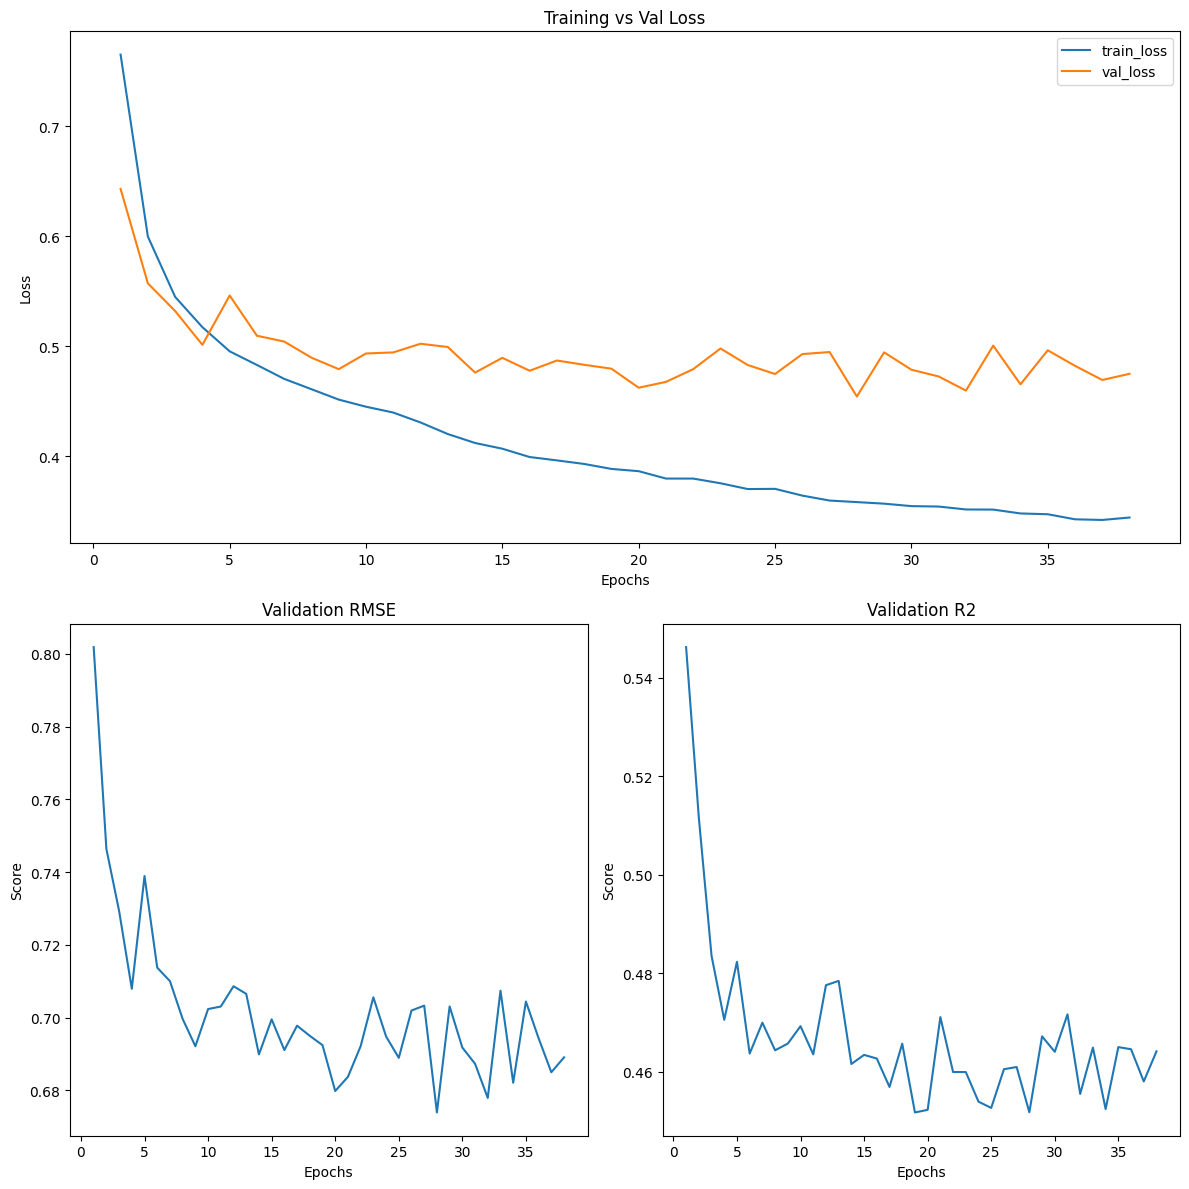

In [58]:
#손실 시각화
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize = (12, 12))

#train/validation loss 그래프
ax1 = plt.subplot(2, 1, 1)
ax1.plot(epochs_range, history['train_loss'], label= 'train_loss')
ax1.plot(epochs_range, history['val_loss'], label= 'val_loss')
ax1.set_title('Training vs Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

#RMSE 그래프
ax2 = plt.subplot(2, 2, 3)
ax2.plot(epochs_range, history['val_rmse'], label='val_rmse')
ax2.set_title('Validation RMSE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Score')

#MAE 그래프
ax3 = plt.subplot(2, 2, 4)
ax3.plot(epochs_range, history['val_mae'], label='val_mae')
ax3.set_title('Validation R2')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Score')

plt.tight_layout()
plt.show()

##Best Model 시각화

lstm_graph 저장 완료


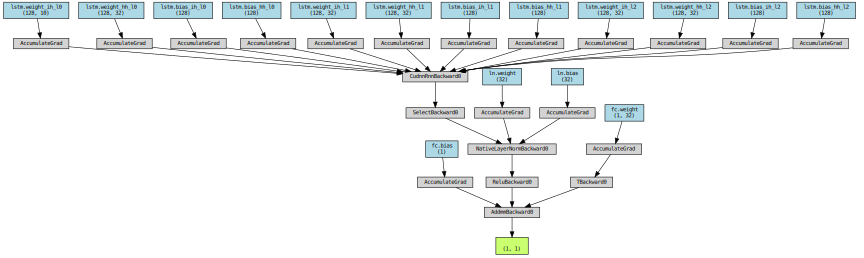

In [59]:
best_model_path = 'checkpoints/best_model.pt'
state_dict = torch.load(best_model_path)
model.load_state_dict(state_dict)

model.eval()

#모델 시각화를 위해 더미 입력 생성
x = torch.randn(1, seq_len, 10).to(device)

output = model(x)
dot = make_dot(output, params = dict(model.named_parameters()))
dot.render("lstm_graph", format="png", cleanup=True)
print("lstm_graph 저장 완료")
dot

##예측 시각화

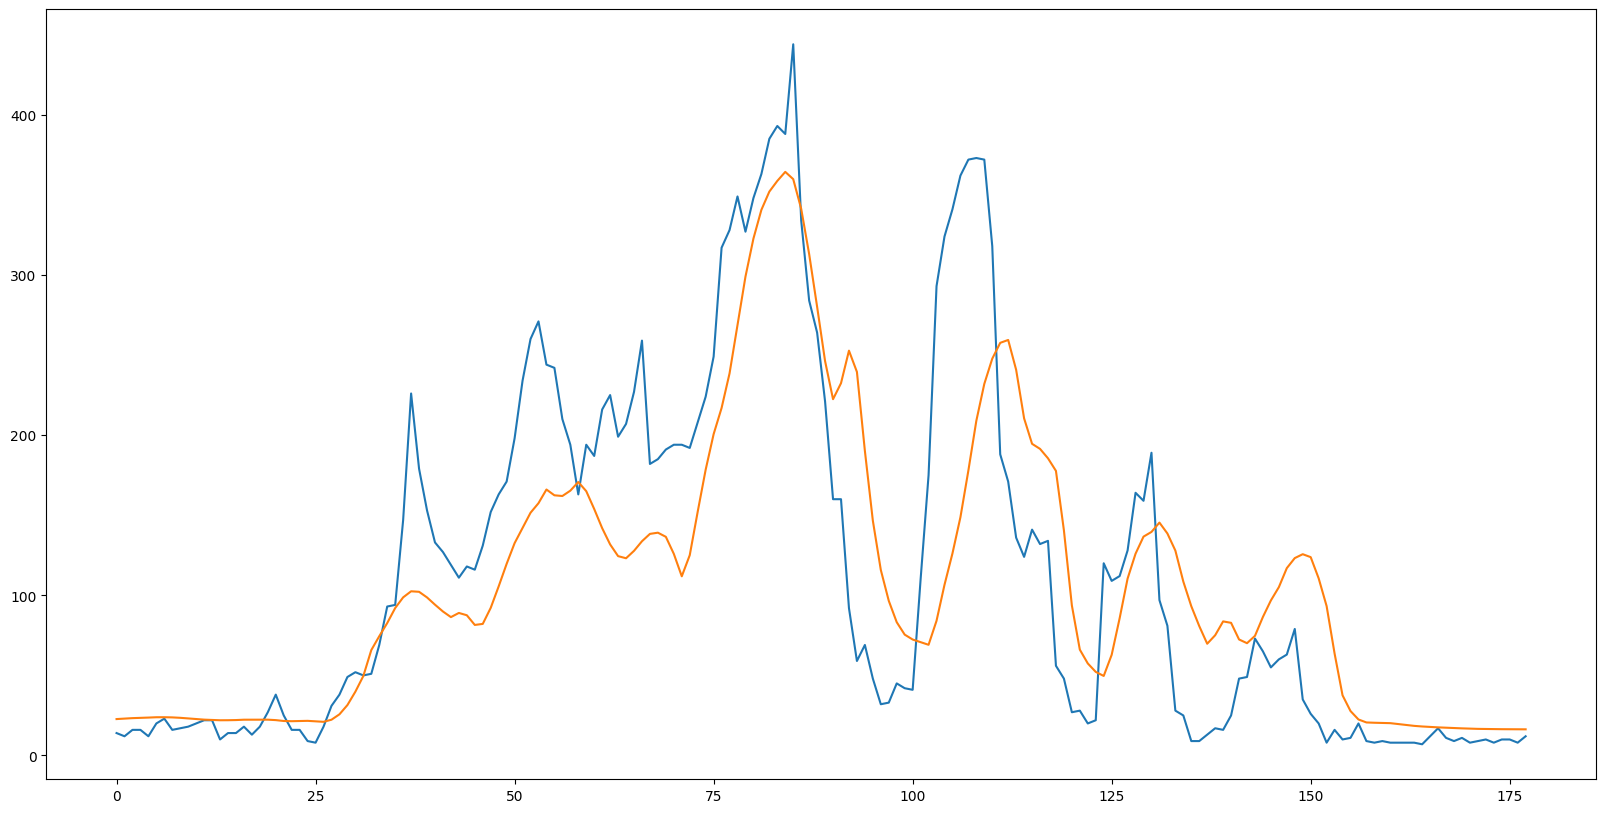

In [60]:
#test 데이터셋 Load
test_ds = PollutionDataset_Test(test_path, seq_len,
                                seq_x_scaler = train_ds.seq_x_scaler,
                                encoder = train_ds.encoder,
                                y_scaler = train_ds.y_scaler)
test_loader = DataLoader(test_ds, batch_size = 100, shuffle = False)

#test데이터셋 예측 수행
prds = []
targets = []
for i, (features, labels) in enumerate(test_loader):
    with torch.no_grad():
        prd = model(features.to(device))
        prds.append(prd.cpu())
        targets.append(labels)

prds_cat = torch.cat(prds, dim=0)
targets_cat = torch.cat(targets, dim=0)


prds = train_ds.y_scaler.inverse_transform(prds_cat.numpy())
targets = train_ds.y_scaler.inverse_transform(targets_cat.numpy())


plt.figure(figsize = (20,10))
plt.plot(range(len(targets)), targets, label = 'label')
plt.plot(range(len(prds)), prds, label = 'pred')
plt.show()